# 38 — Calculate NMRF stress scenario risk

Capitalise factors that fail RFET using conservative horizon-specific stress losses.

SES means Stress Scenario Risk Measure. Each NMRF uses the greater of its assigned horizon and 20 days. Idiosyncratic credit and equity factors are separated from other NMRFs before aggregation.

This step uses: NMRF P&L history, liquidity horizons and calibrated stress losses.

It produces: Factor stress losses, aggregation categories and final SES.

> Basel norm applied: MAR33.16–MAR33.17 calibrate NMRF loss to at least the 97.5% stressed standard and prescribe rho of 0.6 for other NMRFs.

$$SES=\sqrt{\sum ISES_i^2}+\sqrt{\sum ISES_j^2}+\sqrt{(0.6\sum SES_k)^2+0.64\sum SES_k^2}$$

Synthetic inputs are labelled directly in the displayed data. Basel regulatory parameters are loaded separately from versioned configuration.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from frtb_engine.notebook_tools import INR_CRORE, configure_notebooks, crore_table, draw_flow, heatmap

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_ima_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
MANIFEST = json.loads((RUN / 'run_manifest.json').read_text(encoding='utf-8'))
STAGES = {row['stage']: ROOT / row['path'] for row in MANIFEST['artifacts']}
SUMMARY = json.loads((RUN / '27_combined_capital_summary.json').read_text(encoding='utf-8'))

def stage(name):
    return pd.read_csv(STAGES[name])

def money(value):
    return f"INR {float(value) / INR_CRORE:,.2f} crore"

print(f'IMA calculation run used: {RUN_ID}')
print('Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled')

IMA calculation run used: IMA_20260908T033903126517Z
Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled


In [2]:
detail=stage('12_nmrf_ses_detail'); summary=stage('13_nmrf_ses_summary')
display(crore_table(detail,['empirical_stress_loss_inr','parametric_stress_loss_inr','stress_scenario_loss_inr']))
display(crore_table(summary,['idiosyncratic_credit_inr','idiosyncratic_equity_inr','other_nmrf_inr','ses_inr']))
worked=detail.iloc[0]; print(f"{worked.risk_factor_id}: max(empirical {money(worked.empirical_stress_loss_inr)}, parametric {money(worked.parametric_stress_loss_inr)}) = {money(worked.stress_scenario_loss_inr)}")

,risk_factor_id,broad_risk_class,ses_category,liquidity_horizon_days,Empirical Stress Loss (INR crore),Parametric Stress Loss (INR crore),Stress Scenario Loss (INR crore),worst_scenario_end_date,stress_window_start,stress_window_end,calibration_method,input_data_status
0,CDX_IG_S42_3_7_5.0Y,CREDIT_SPREAD,OTHER_NMRF,120,0.4737,0.9332,0.9332,2023-03-03,2022-04-27,2023-04-11,Worst rolling annual window; maximum empirical...,SYNTHETIC_REGIME_AWARE
1,EU_UTILITY_VOL_1.0Y,CREDIT_SPREAD,OTHER_NMRF,120,0.2052,0.4825,0.4825,2022-11-02,2021-12-13,2022-11-25,Worst rolling annual window; maximum empirical...,SYNTHETIC_REGIME_AWARE
2,EU_UTILITY_VOL_3.0Y,CREDIT_SPREAD,OTHER_NMRF,120,0.2669,0.5295,0.5295,2022-11-02,2022-04-25,2023-04-07,Worst rolling annual window; maximum empirical...,SYNTHETIC_REGIME_AWARE
3,INDIA_METALS_3.0Y,CREDIT_SPREAD,OTHER_NMRF,60,0.0972,0.2196,0.2196,2023-03-13,2022-04-25,2023-04-07,Worst rolling annual window; maximum empirical...,SYNTHETIC_REGIME_AWARE
4,INDIA_METALS_5.0Y,CREDIT_SPREAD,OTHER_NMRF,60,0.1341,0.2445,0.2445,2022-11-25,2021-12-15,2022-11-29,Worst rolling annual window; maximum empirical...,SYNTHETIC_REGIME_AWARE
5,INDIA_SMALLCAP,EQUITY,OTHER_NMRF,20,0.4014,1.2568,1.2568,2020-07-21,2019-09-03,2020-08-17,Worst rolling annual window; maximum empirical...,SYNTHETIC_REGIME_AWARE
6,RMBS_PRIME_2026_3.0Y,CREDIT_SPREAD,OTHER_NMRF,120,0.2002,0.3407,0.3407,2020-09-22,2020-01-24,2021-01-07,Worst rolling annual window; maximum empirical...,SYNTHETIC_REGIME_AWARE
7,RMBS_PRIME_2026_5.0Y,CREDIT_SPREAD,OTHER_NMRF,120,0.5376,0.8206,0.8206,2022-11-02,2021-12-03,2022-11-17,Worst rolling annual window; maximum empirical...,SYNTHETIC_REGIME_AWARE


,Idiosyncratic Credit (INR crore),Idiosyncratic Equity (INR crore),Other Nmrf (INR crore),Ses (INR crore)
0,0.0000,0.0000,3.2954,3.2954


CDX_IG_S42_3_7_5.0Y: max(empirical INR 0.47 crore, parametric INR 0.93 crore) = INR 0.93 crore


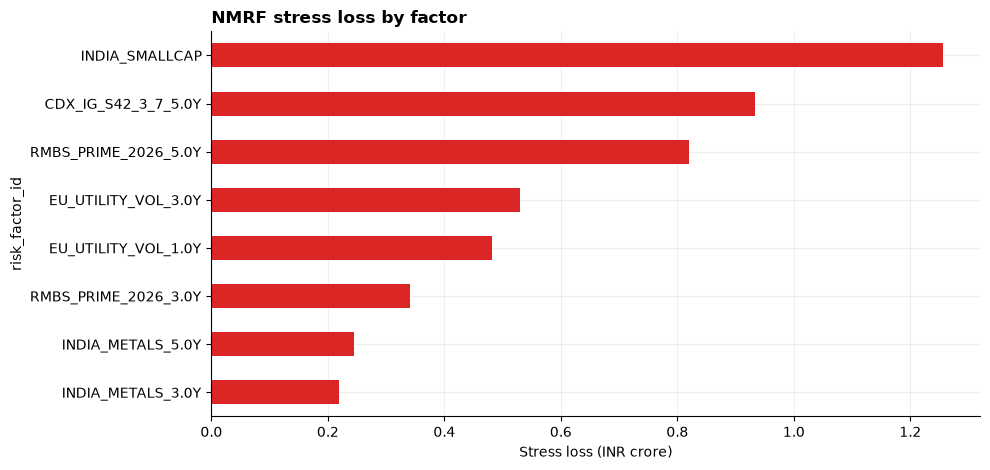

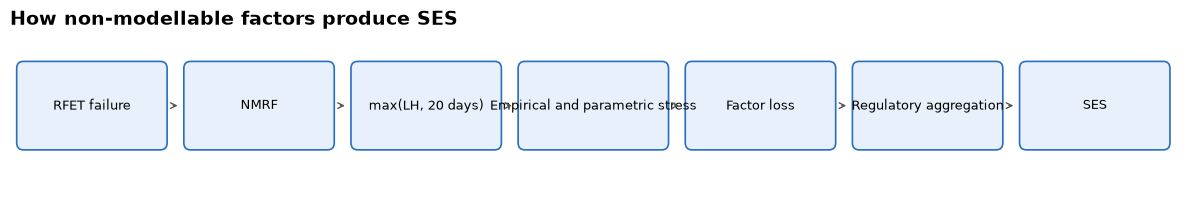

In [3]:
ax=(detail.set_index('risk_factor_id').stress_scenario_loss_inr/INR_CRORE).sort_values().plot(kind='barh',color='#DC2626'); ax.set_xlabel('Stress loss (INR crore)'); ax.set_title('NMRF stress loss by factor',loc='left',weight='bold'); plt.tight_layout(); plt.show()
draw_flow(['RFET failure','NMRF','max(LH, 20 days)','Empirical and parametric stress','Factor loss','Regulatory aggregation','SES'],'How non-modellable factors produce SES',wrap_after=7)

The horizontal bars rank NMRFs by their selected stress-scenario loss, revealing which failed factors drive SES. The flow diagram shows why these losses remain outside modellable-factor ES: RFET failure leads to a horizon-adjusted stress loss and then the prescribed regulatory aggregation.